In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from tqdm import tqdm  # Provides the progress of model running

In [4]:
boston = pd.read_csv('D:/Machine_Learning/Datasets/Boston.csv')

X , y = boston.drop('medv', axis=1), boston['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26)

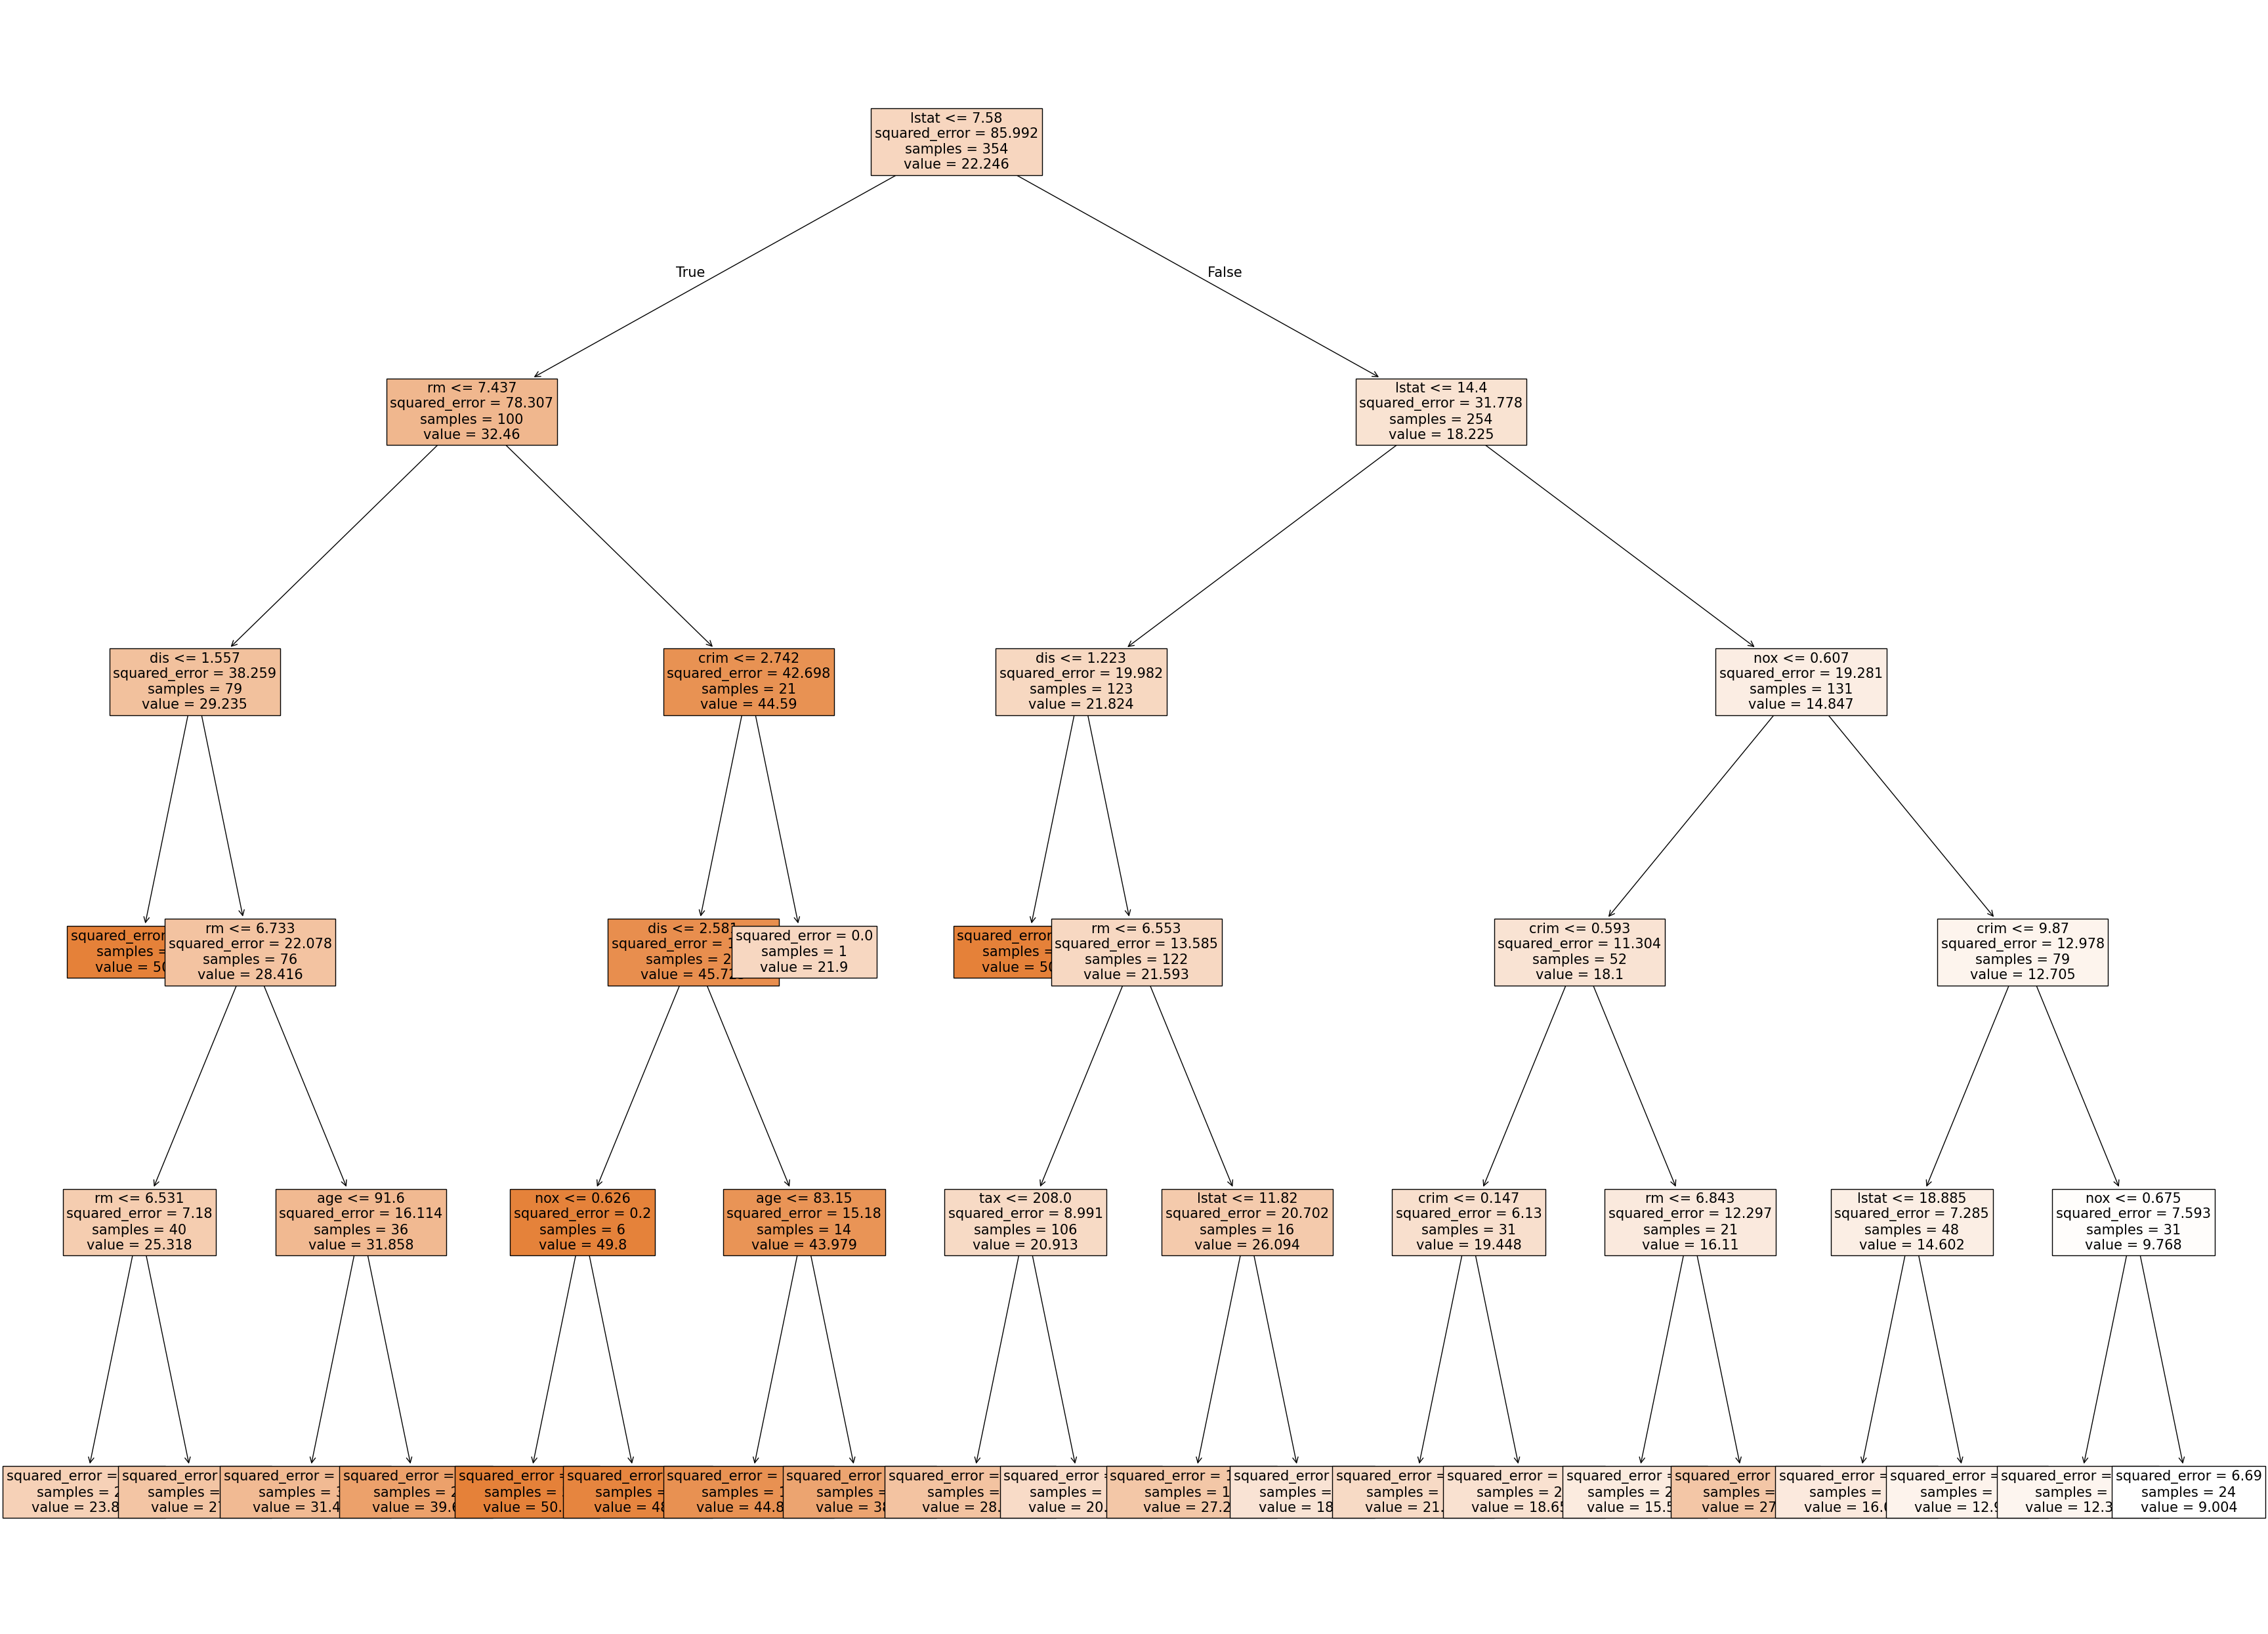

In [6]:
dtc = DecisionTreeRegressor(random_state=26, max_depth=5)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,25))
plot_tree(dtc, feature_names=list(X.columns), filled=True, fontsize=15)
plt.tight_layout()
plt.show()

In [7]:
depths = [1,2,3,5,None]  # take random values instead of np.arange
splits = [2,4,8,10,20,30,50,100]
leaves= [1,4,8,10,20,30,46,50,100]
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeRegressor(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_test)
            
            
            scores.append([d, s, l, r2_score(y_test, y_pred)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'R2 Score' ])
df_scores.sort_values(['R2 Score'], ascending=False).head()

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.27it/s]


,Depth,Splits,Leaves,R2 Score
216,5.0,2,1,0.840638
225,5.0,4,1,0.840638
234,5.0,8,1,0.839735
243,5.0,10,1,0.839735
261,5.0,30,1,0.835667


# best tree

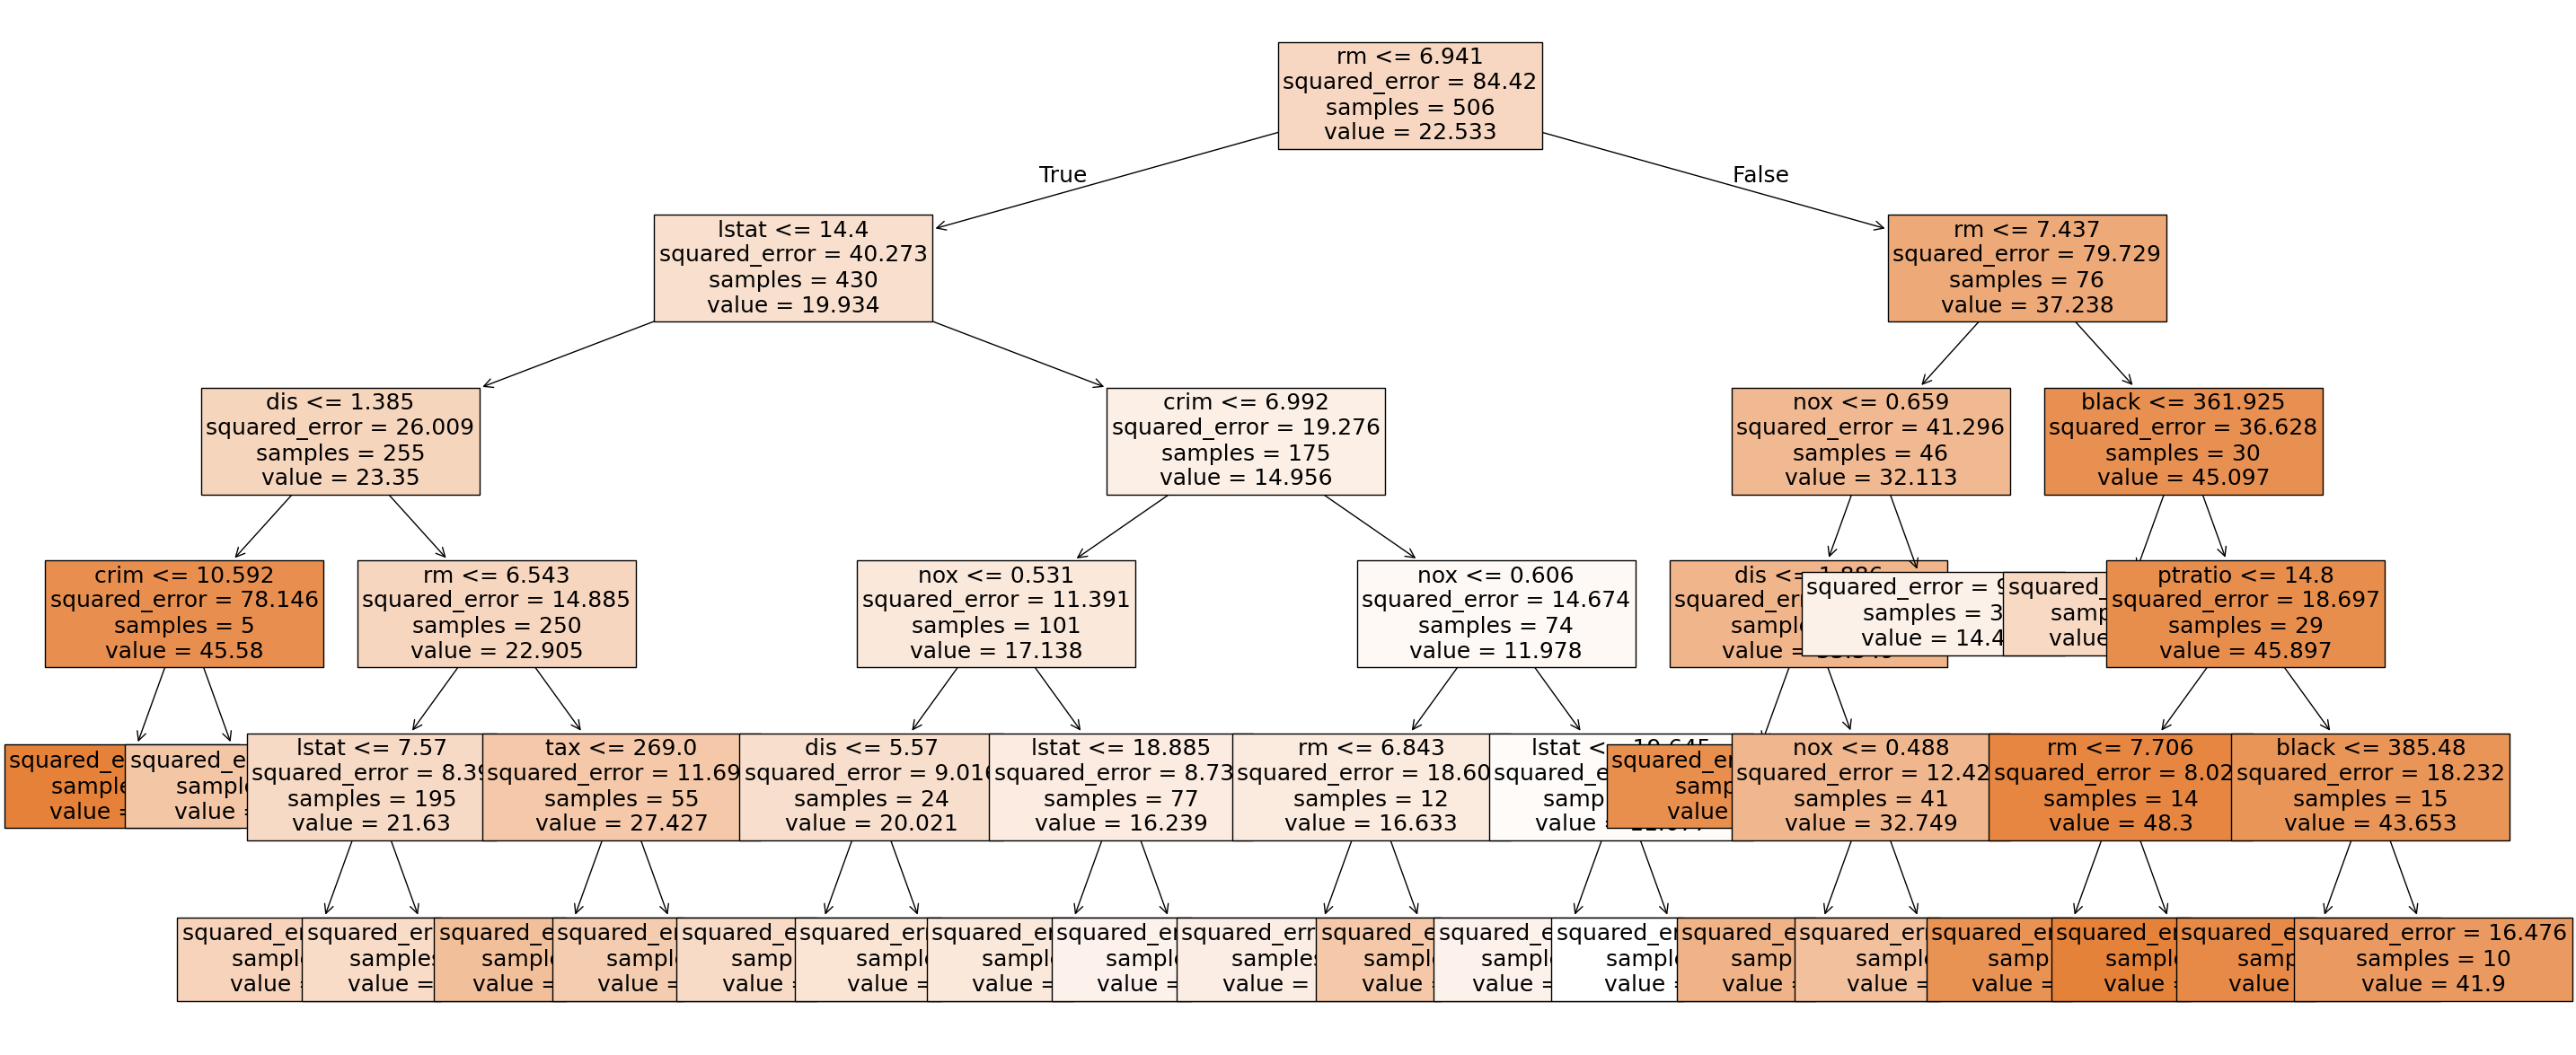

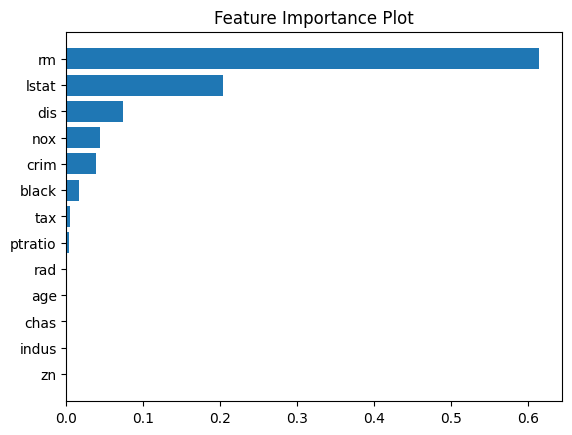

In [12]:
bm =  DecisionTreeRegressor(random_state=26, max_depth=5, min_samples_split=4, min_samples_leaf=1)
bm.fit(X,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X.columns), filled=True, fontsize=18)
plt.show()

df_imp = pd.DataFrame({'feature':X.columns, 'importance':bm.feature_importances_})
df_imp = df_imp.sort_values('importance')
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()